In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv("placement.csv")

In [3]:
dataset

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
213,214,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0


In [4]:
dataset.isnull().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

In [24]:
dataset["salary"] = dataset["salary"].fillna(0)

In [25]:
dataset.isnull().sum()

sl_no               0
gender              0
ssc_p               0
ssc_b               0
hsc_p               0
hsc_b               0
hsc_s               0
degree_p            0
degree_t            0
workex              0
etest_p             0
specialisation      0
mba_p               0
status              0
salary              0
salary_zscore     215
dtype: int64

In [5]:
dataset["status"].value_counts()

status
Placed        148
Not Placed     67
Name: count, dtype: int64

In [6]:
dataset.groupby("status")[["ssc_p","hsc_p","degree_p", "etest_p", "mba_p"]].mean()

,ssc_p,hsc_p,degree_p,etest_p,mba_p
status,,,,,
Not Placed,57.544030,58.395522,61.134179,69.587910,61.612836
Placed,71.721486,69.926554,68.740541,73.238041,62.579392


In [7]:
dataset[["salary","mba_p"]].corr()

,salary,mba_p
salary,1.000000,0.175013
mba_p,0.175013,1.000000


In [8]:
dataset.groupby("specialisation")["salary"].describe()

,count,mean,std,min,25%,50%,75%,max
specialisation,,,,,,,,
Mkt&Fin,95.0,298852.631579,108190.530165,200000.0,240000.0,270000.0,300000.0,940000.0
Mkt&HR,53.0,270377.358491,54784.271471,200000.0,240000.0,255000.0,300000.0,450000.0


In [9]:
dataset[dataset["salary"]> 500000].groupby("specialisation").value_counts()

specialisation  sl_no  gender  ssc_p  ssc_b    hsc_p  hsc_b    hsc_s     degree_p  degree_t   workex  etest_p  mba_p  status  salary  
Mkt&Fin         120    M       60.8   Central  68.40  Central  Commerce  64.6      Comm&Mgmt  Yes     82.66    64.34  Placed  940000.0    1
                151    M       71.0   Central  58.66  Central  Science   58.0      Sci&Tech   Yes     56.00    61.30  Placed  690000.0    1
                178    F       73.0   Central  97.00  Others   Commerce  79.0      Comm&Mgmt  Yes     89.00    70.81  Placed  650000.0    1
Name: count, dtype: int64

In [10]:
import scipy.stats as stats
stats.f_oneway(dataset['etest_p'],dataset['mba_p'])

F_onewayResult(statistic=np.float64(98.64487057324708), pvalue=np.float64(4.672547689133693e-21))

In [11]:
from scipy.stats import ttest_ind
#dataset=dataset.dropna()
sci_tech=dataset[dataset['degree_t']=='Sci&Tech '] ['salary'].dropna()
mkt_hr=dataset[dataset['specialisation']=='Mkt&Hr']['salary'].dropna()
result=ttest_ind(sci_tech,mkt_hr,equal_var=False)
#print("Sci&Tech:",len(sci_tech))
#print("Mkt&Hr:",len(mkt_hr))
print(result)

TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.float64(nan))


C:\Users\Sheshathri\AppData\Local\Temp\ipykernel_22732\1495697374.py:5: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  result=ttest_ind(sci_tech,mkt_hr,equal_var=False)


In [12]:
dataset["degree_t"].unique()
dataset["specialisation"].unique()
dataset.groupby("degree_t")["salary"].count()
dataset.groupby("specialisation")["salary"].count()

specialisation
Mkt&Fin    95
Mkt&HR     53
Name: salary, dtype: int64

In [13]:
dataset.groupby("degree_t")["salary"].count()

degree_t
Comm&Mgmt    102
Others         5
Sci&Tech      41
Name: salary, dtype: int64

In [14]:
dataset["degree_t"].unique()

<StringArray>
['Sci&Tech', 'Comm&Mgmt', 'Others']
Length: 3, dtype: str

In [15]:
from scipy.stats import ttest_ind

sci_tech = dataset.loc[dataset["degree_t"]=="Sci&Tech", "salary"].dropna()
mkt_hr = dataset.loc[dataset["specialisation"]=="Mkt&HR", "salary"].dropna()

result = ttest_ind(sci_tech, mkt_hr, equal_var=False)
print(result)

TtestResult(statistic=np.float64(2.5503380163544116), pvalue=np.float64(0.013410910580431394), df=np.float64(58.292962742666546))


In [16]:
from scipy.stats import zscore
dataset["salary_zscore"]=zscore(dataset["salary"])
print(dataset[["salary","salary_zscore"]].head())

     salary  salary_zscore
0  270000.0            NaN
1  200000.0            NaN
2  250000.0            NaN
3       NaN            NaN
4  425000.0            NaN


In [17]:
from scipy.stats import norm
mean=dataset["salary"].mean()
std=dataset["salary"].std()
z1=(700000-mean)/std
z2=(900000-mean)/std
porbability=norm.cdf(z2)-norm.cdf(z1)
print("Mean:",mean)
print("std:",std)
print("z1:",z1)
print("z2:",z2)
print("Porbability:",porbability)

Mean: 288655.4054054054
std: 93457.45241958875
z1: 4.401410309664898
z2: 6.541421564220343
Porbability: 5.377445759013888e-06


In [18]:
from scipy.stats import ttest_rel

sci= dataset[dataset["degree_t"]=="Sci&Tech"]
result = ttest_rel(sci["etest_p"],sci["mba_p"] )
print(result)

TtestResult(statistic=np.float64(5.0049844583693615), pvalue=np.float64(5.5179206005054e-06), df=np.int64(58))


In [21]:
dataset.groupby("specialisation")["salary"].mean()

specialisation
Mkt&Fin    298852.631579
Mkt&HR     270377.358491
Name: salary, dtype: float64

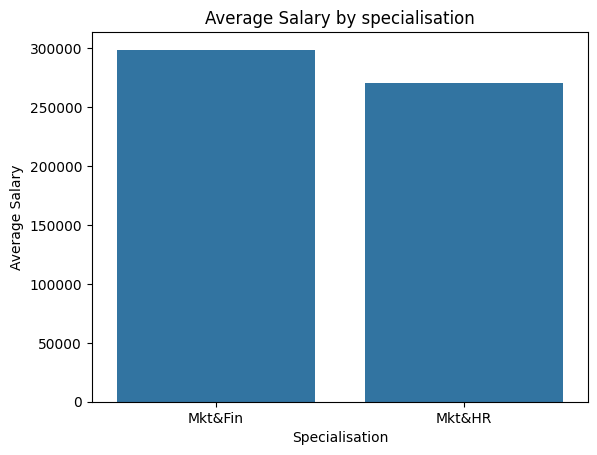

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
avg_salary=(dataset.groupby("specialisation")["salary"].mean().reset_index())
sns.barplot(data=avg_salary,x="specialisation",y="salary")
plt.title("Average Salary by specialisation")
plt.xlabel("Specialisation")
plt.ylabel("Average Salary")
plt.show()


In [19]:
dataset.corr(numeric_only=True)["salary"].sort_values(ascending=False)

salary           1.000000
etest_p          0.178307
mba_p            0.175013
hsc_p            0.076819
sl_no            0.063764
ssc_p            0.035330
degree_p        -0.019272
salary_zscore         NaN
Name: salary, dtype: float64

In [20]:
dir(dataset)

['T',
 '_AXIS_LEN',
 '_AXIS_ORDERS',
 '_AXIS_TO_AXIS_NUMBER',
 '_HANDLED_TYPES',
 '__abs__',
 '__add__',
 '__and__',
 '__annotations__',
 '__array__',
 '__array_priority__',
 '__array_ufunc__',
 '__arrow_c_stream__',
 '__bool__',
 '__class__',
 '__contains__',
 '__copy__',
 '__dataframe__',
 '__deepcopy__',
 '__delattr__',
 '__delitem__',
 '__dict__',
 '__dir__',
 '__divmod__',
 '__doc__',
 '__eq__',
 '__finalize__',
 '__firstlineno__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__iand__',
 '__ifloordiv__',
 '__imod__',
 '__imul__',
 '__init__',
 '__init_subclass__',
 '__invert__',
 '__ior__',
 '__ipow__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__ixor__',
 '__le__',
 '__len__',
 '__lt__',
 '__matmul__',
 '__mod__',
 '__module__',
 '__mul__',
 '__ne__',
 '__neg__',
 '__new__',
 '__or__',
 '__pandas_priority__',
 '__pos__',
 '__pow__',
 '__radd__',
 '__rand__',
 '__rdivmod__

In [ ]:
print(dataset.dtypes)

In [ ]:
print(dataset.select_dtypes(include='number').columns)

In [ ]:
dataset.cov(numeric_only=True)

In [ ]:
dataset.corr(numeric_only=True)

In [ ]:
dataset[["ssc_p", "hsc_p", "degree_p", "etest_p", "mba_p", "salary"]]

In [ ]:
data_vif=dataset[["ssc_p", "hsc_p", "degree_p", "etest_p", "mba_p", "salary"]].dropna()

In [ ]:
dataset[["ssc_p", "hsc_p", "degree_p", "etest_p", "mba_p", "salary"]]

In [ ]:
print(dataset.select_dtypes(include=['object', 'string']).columns)

In [ ]:
numeric_dataset=dataset.select_dtypes(include='number')
numeric_dataset.to_numpy(dtype=float)

In [ ]:
dataset.dtypes

In [ ]:
numeric_dataset.drop('sl_no',inplace=True,axis=1)

In [ ]:
numeric_dataset.cov()

#### Independent Sample - Unpaired Test

#### Different Group(Male,Female) but same condition (salary)

In [ ]:
dataset['gender'].unique()

In [ ]:
dataset[dataset['gender']=='F']

In [ ]:
dataset[dataset['gender']=='F']["salary"]

In [ ]:
from scipy.stats import ttest_ind
dataset=dataset.dropna()
male=dataset[dataset['gender']=='M']['salary']
female=dataset[dataset['gender']=='F']['salary']

In [ ]:
ttest_ind(male,female)

#### Dependent Sample -Paired Test

#### Same Group(Male) but different condition (ssc_p,hsc_p)

In [ ]:
from scipy.stats import ttest_rel
dataset=dataset.dropna()
hsc=dataset[dataset['hsc_s']=='Commerce'] ['mba_p']
hsc1=dataset[dataset['hsc_s']=='Commerce']['etest_p']

In [ ]:
ttest_rel(hsc,hsc1)

### ANAVO Analysis of variance
### One way classification
### Reject Null Hypothesis p<0.05
### Accept Null Hypothesi and Reject Alternate Hypothsis

In [ ]:
import scipy.stats as stats
stats.f_oneway(dataset['ssc_p'],dataset['hsc_p'],dataset['degree_p'])

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

#perform two way ANAVO
model=ols('degree_p  ~ C(degree_p) + C(hsc_p) + C(ssc_p):C(hsc_p)',data=dataset).fit()
anova_tabl=sm.stats.anova_lm(model,typ=2)